In [1]:
!pip install yfinance pandas streamlit sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.3 MB/s eta 0:00:00


In [2]:
#Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

In [3]:
# Indian stocks on NSE
stocks = ["RELIANCE.NS", "TCS.NS" , "INFY.NS", "HDFCBANK.NS", "WIPRO.NS"]
DATA_PATH = "data/raw_stock_data.csv"
print(DATA_PATH)
os.makedirs("data", exist_ok=True)





data/raw_stock_data.csv


In [4]:
#fetch data

if os.path.exists(DATA_PATH):
    print("📂 Loading data from CSV...")
    data = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
else:
    print("🌐 Fetching data from yfinance...")
    data = yf.download(stocks, period="3mo", interval="1d")["Close"]
    data.to_csv(DATA_PATH)
    print(" Data fetched and saved!")

🌐 Fetching data from yfinance...


/tmp/ipykernel_151/543442021.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, period="3mo", interval="1d")["Close"]
[*********************100%***********************]  5 of 5 completed

 Data fetched and saved!


In [18]:
def predict_stock(data, stock_name):

    print(f"\n🔍 Processing {stock_name}...")

    # Step 1: Select stock data
    stock_data = data[[stock_name]].copy()
    stock_data = stock_data.dropna()
    stock_data.rename(columns={stock_name: "Close"}, inplace=True)

    # Step 2: Feature Engineering
    stock_data["Days"] = range(len(stock_data))
    stock_data["MA_10"] = stock_data["Close"].rolling(10).mean()

    # Remove NaN after rolling
    stock_data = stock_data.dropna()

    # Step 3: Prepare ML data
    X = stock_data[["Days"]]
    y = stock_data["Close"]

    # Step 4: Train model
    model = LinearRegression()
    model.fit(X, y)

    # Step 5: Predict next 7 days
    last_day = stock_data["Days"].iloc[-1]

    future_days = pd.DataFrame({
        "Days": [last_day + i for i in range(1, 8)]
    })

    predictions = model.predict(future_days)

    # Step 6: Save processed data
    stock_data.to_csv(f"data/{stock_name}_processed.csv", index=False)

    # Save predictions
    pred_df = pd.DataFrame({
        "Day": range(1, 8),
        "Predicted Price": predictions
    })
    pred_df.to_csv(f"data/{stock_name}_predictions.csv", index=False)

    # Step 7: Plot
    plt.figure(figsize=(10, 5))

    plt.plot(stock_data["Days"], stock_data["Close"], label="Actual Price")

    plt.plot(
        range(last_day + 1, last_day + 8),
        predictions,
        linestyle="--",
        label="Predicted Price"
    )

    plt.title(f"{stock_name} Price Prediction")
    plt.xlabel("Days")
    plt.ylabel("Price (INR ₹)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Step 8: Print predictions
    print(f"\n📈 {stock_name} Next 7 Days Prediction:")
    for i, price in enumerate(predictions, 1):
        print(f"Day {i}: ₹{price:.2f}")



🔍 Processing RELIANCE.NS...


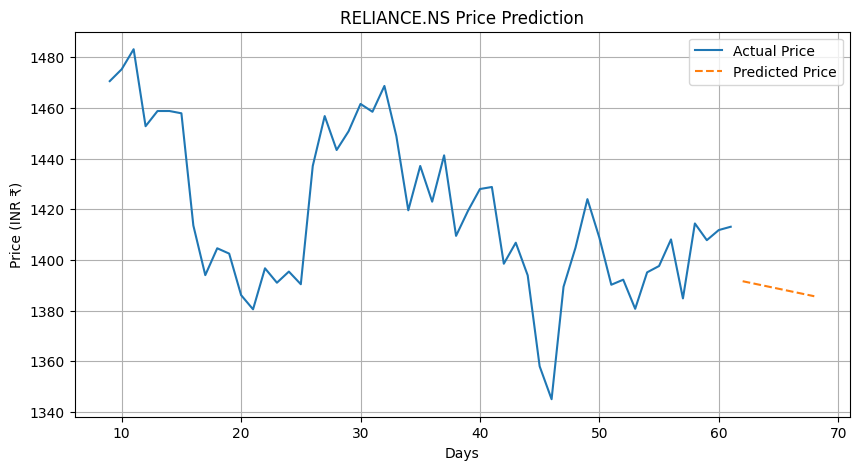


📈 RELIANCE.NS Next 7 Days Prediction:
Day 1: ₹1391.60
Day 2: ₹1390.61
Day 3: ₹1389.62
Day 4: ₹1388.63
Day 5: ₹1387.64
Day 6: ₹1386.65
Day 7: ₹1385.66

🔍 Processing TCS.NS...


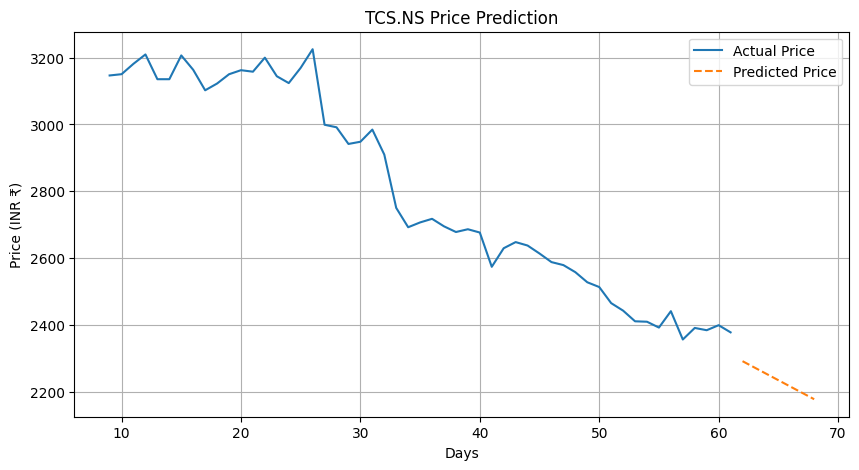


📈 TCS.NS Next 7 Days Prediction:
Day 1: ₹2291.06
Day 2: ₹2272.08
Day 3: ₹2253.09
Day 4: ₹2234.10
Day 5: ₹2215.11
Day 6: ₹2196.13
Day 7: ₹2177.14

🔍 Processing INFY.NS...


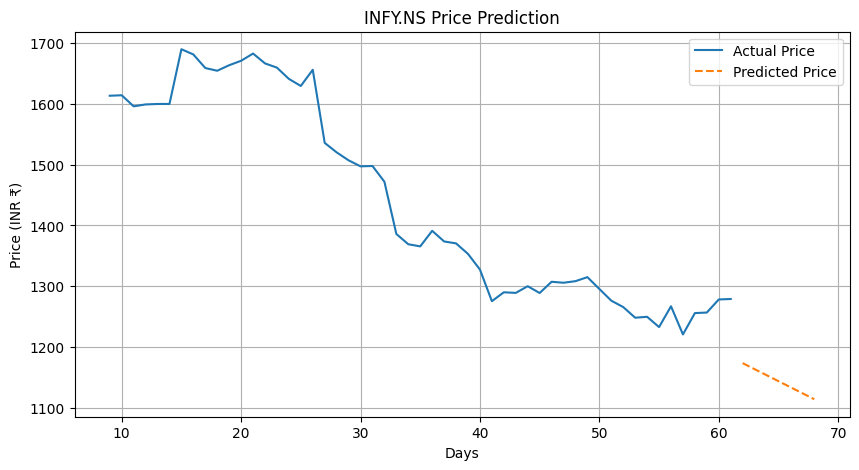


📈 INFY.NS Next 7 Days Prediction:
Day 1: ₹1173.59
Day 2: ₹1163.70
Day 3: ₹1153.81
Day 4: ₹1143.93
Day 5: ₹1134.04
Day 6: ₹1124.15
Day 7: ₹1114.26

🔍 Processing HDFCBANK.NS...


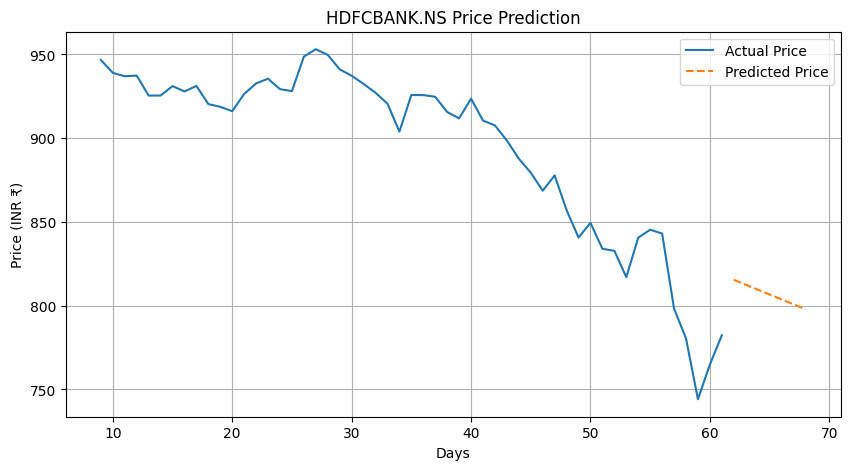


📈 HDFCBANK.NS Next 7 Days Prediction:
Day 1: ₹815.46
Day 2: ₹812.53
Day 3: ₹809.60
Day 4: ₹806.67
Day 5: ₹803.75
Day 6: ₹800.82
Day 7: ₹797.89

🔍 Processing WIPRO.NS...


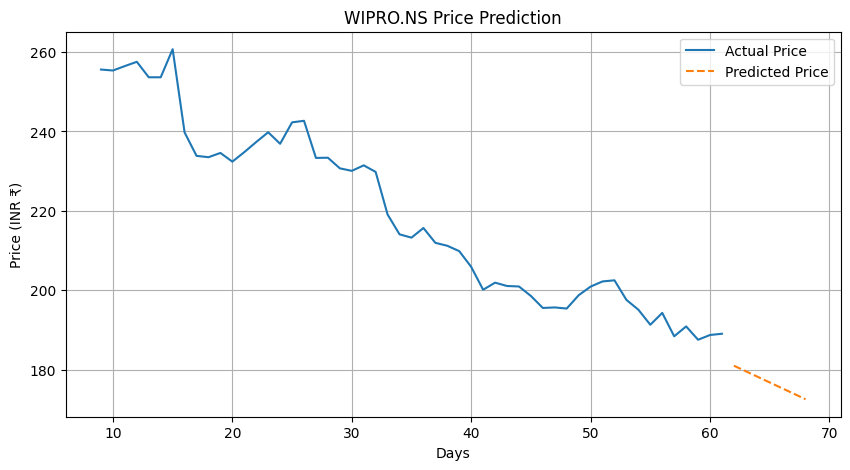


📈 WIPRO.NS Next 7 Days Prediction:
Day 1: ₹181.01
Day 2: ₹179.60
Day 3: ₹178.19
Day 4: ₹176.78
Day 5: ₹175.38
Day 6: ₹173.97
Day 7: ₹172.56


In [19]:
# Call the prediction function for each stock
for stock_name in stocks:
    predict_stock(data, stock_name)